In [1]:
import numpy as np
import datetime
import matplotlib.pyplot as plt
import pickle

In [2]:
roots = "C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\dados_brutos\\GPS\\"
file1 = "Current Track_ 06 NOV 2023 08_46.gpx"
file2 = 'TrackPoints.gpx'

In [3]:
with open(roots+file1) as src:
    f1 = src.readlines()

In [4]:
lat1 = []
lon1 = []
time1 = []

teste = 0

for li in f1:
    if '<trkseg>' in li:
        teste = 1
    if teste == 1:
        if 'trkpt lat' in li:
            liq = li.split('"')
            lat1.append(float(liq[1]))
            lon1.append(float(liq[3]))
        if '<time>' in li:
            ano = int(li[14:18])
            mes = int(li[19:21])
            dia = int(li[22:24])
            hora = (int(li[25:27])-3)%24
            minuto = int(li[28:30])
            seg = int(li[31:33])
            
            trasht = datetime.datetime.timestamp(datetime.datetime(ano, mes, dia, hora, minuto, seg))
            time1.append(trasht)
            


In [5]:
datetime.datetime.fromtimestamp(time1[5220]), datetime.datetime.fromtimestamp(time1[5336])

(datetime.datetime(2023, 11, 28, 6, 15, 22),
 datetime.datetime(2023, 11, 28, 6, 25))

In [6]:
print(np.mean(lon1[5336]), np.mean(lat1[5336]))

-52.10817743092775 -32.16954790055752


(np.float64(-52.14845094596967),
 np.float64(-52.089096133131534),
 np.float64(-32.200815928168595),
 np.float64(-32.161469916813076))

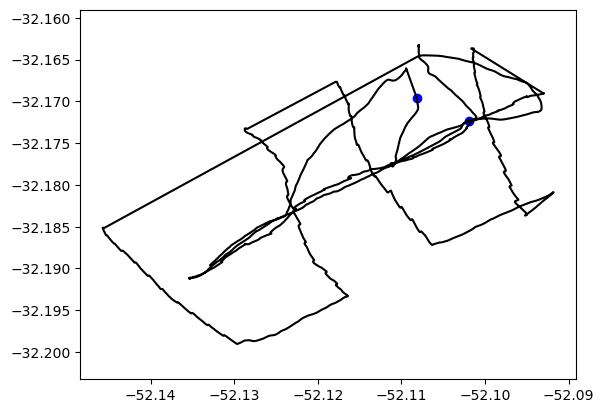

In [7]:
plt.plot(lon1[5092:-1], lat1[5092:-1], color ='k')
#adcp 1
plt.scatter(np.mean(lon1[5220]), np.mean(lat1[5220]), color ='b')
plt.scatter(np.mean(lon1[5336]), np.mean(lat1[5336]), color ='b')


plt.axis('equal')

(np.float64(-52.14845094596967),
 np.float64(-52.089096133131534),
 np.float64(-32.200815928168595),
 np.float64(-32.161469916813076))

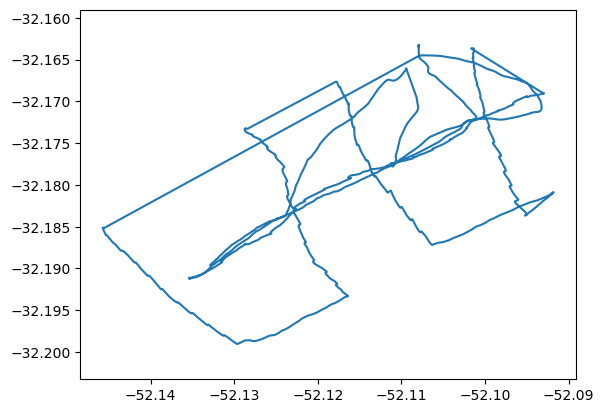

In [8]:
plt.plot(lon1[5092:-1], lat1[5092:-1])
plt.axis('equal')

In [9]:
with open(roots+file2) as src:
    f2 = src.readlines()

In [10]:
lat2 = []
lon2 = []
time2 = []

teste = 0

for li in f2:
    if '<wpt ' in li:
        liq = li.split('"')
        lat2.append(float(liq[1]))
        lon2.append(float(liq[3]))
    if '<time>' in li:
        ano = int(li[10:14])
        mes = int(li[15:17])
        dia = int(li[18:20])
        hora = (int(li[21:23])-3)%24
        minuto = int(li[24:26])
        seg = int(li[27:29])

        trasht = datetime.datetime(ano, mes, dia, hora, minuto, seg)
        time2.append(trasht)
            


In [11]:
lon2[0], lat2[0], lon2[1], lat2[1], lon2[2], lat2[2], lon2[3], lat2[3], lon2[4], lat2[4]

(-52.101839035749435,
 -32.17228903435171,
 -52.1109380107373,
 -32.17749796807766,
 -52.12467100471258,
 -32.18398698605597,
 -52.134110033512115,
 -32.19077498652041,
 -52.13540302589536,
 -32.191106993705034)

(np.float64(-52.14845094596967),
 np.float64(-52.089096133131534),
 np.float64(-32.200815928168595),
 np.float64(-32.161469916813076))

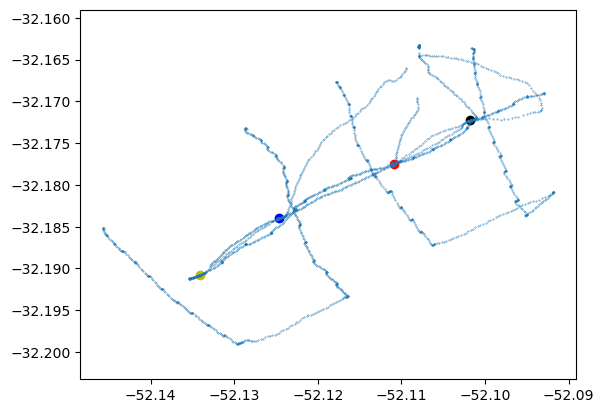

In [12]:
plt.scatter(lon2[0], lat2[0], color ='k')
plt.scatter(lon2[1], lat2[1], color ='r')
plt.scatter(lon2[2], lat2[2], color ='b')
plt.scatter(lon2[3], lat2[3], color ='y')
plt.axis('equal')
plt.scatter(lon1[5092:-1], lat1[5092:-1], s= 0.1)
plt.axis('equal')

In [13]:
type(np.array([time1]))

numpy.ndarray

In [14]:
dados_gps = np.array([np.array(time1[5092:-1]), np.array(lon1[5092:-1]), np.array(lat1[5092:-1])])
type(dados_gps)

numpy.ndarray

In [15]:

with open('C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\dados_gps.pkl', 'wb') as file:
    pickle.dump(dados_gps, file)